# Convolution

## What is Convolution?

Convolution is a mathematical operation that lets us extract features from images.

## Why is this useful?

Images contain patterns:

- edges
- textures
- shapes

Convolution helps detect these patterns automatically.

## Generate html with:

```
jupyter nbconvert --to slides generate_images_presentation.ipynb
```

In [60]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My Drive/Colab Notebooks/WignerCamp2026
except:
    IN_COLAB = False
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running on Local computer


In [61]:
import os
from typing import Dict

import torch
import torch.nn.functional as F
import torch.nn
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [62]:
def load_image(path: str) -> torch.Tensor:
    """
    Load an image and convert it to a PyTorch tensor.

    Parameters
    ----------
    path : str
        Path to the input image.

    Returns
    -------
    torch.Tensor
        Tensor of shape (1, C, H, W) with values in [0, 1].
    """
    image = Image.open(path).convert("RGB")
    transform = transforms.ToTensor()
    tensor = transform(image).unsqueeze(0)  # (1, C, H, W)
    return tensor


def save_image(tensor: torch.Tensor, path: str) -> None:
    """
    Save a PyTorch tensor as an image.

    Parameters
    ----------
    tensor : torch.Tensor
        Tensor of shape (1, C, H, W).
    path : str
        Output file path.
    """
    tensor = tensor.squeeze(0).clamp(0, 1)
    transform = transforms.ToPILImage()
    image = transform(tensor)
    image.save(path)

def apply_kernel(image: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
    """
    Apply a convolution kernel to an RGB image.

    Parameters
    ----------
    image : torch.Tensor
        Input image tensor of shape (1, C, H, W).
    kernel : torch.Tensor
        Kernel tensor of shape (1, 1, kH, kW).

    Returns
    -------
    torch.Tensor
        Output image tensor of shape (1, C, H, W).
    """
    C = image.shape[1]

    # Apply same kernel independently to each channel
    kernel = kernel.repeat(C, 1, 1, 1)

    padding = kernel.shape[-1] // 2

    output = F.conv2d(image, kernel, padding=padding, groups=C)

    return output


In [63]:
def tensor_to_image(t: torch.Tensor) -> np.ndarray:
    """
    Convert tensor (1, C, H, W) → numpy (H, W, C).
    """
    t = t.squeeze(0).detach().cpu()
    return t.permute(1, 2, 0).numpy()

def normalize(img: torch.Tensor) -> torch.Tensor:
    """
    Normalize tensor for visualization.

    Parameters
    ----------
    img : torch.Tensor

    Returns
    -------
    torch.Tensor
    """
    min_val = img.min()
    max_val = img.max()
    if max_val > min_val:
        img = (img - min_val) / (max_val - min_val)
    return img

def plot_convolution_diagram(
    image_path: str,
    kernel: torch.Tensor,
    title: str = "",
    save_path: str | None = None,
) -> None:
    """
    Plot [image] * [kernel] = [result] with improved layout.
    """

    plt.rcParams.update({
        "font.size": 25,
        "text.usetex": True,
        "font.family": "serif",
    })
    image = load_image(image_path)

    img_np = tensor_to_image(image)
    result = apply_kernel(image, kernel)
    res_np = tensor_to_image(normalize(result))

    kernel_np = kernel.squeeze().detach().cpu().numpy()

    fig = plt.figure(figsize=(9, 5))

    # Wider table, narrow symbols
    gs = fig.add_gridspec(
        1, 5,
        width_ratios=[3, 0.15, 4, 0.15, 3]
    )

    # --- Original image ---
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img_np)
    ax0.axis("off")

    # --- Star ---
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.text(0.5, 0.5, r"$\ast$", ha="center", va="center")
    ax1.axis("off")

    # --- Kernel table ---
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.axis("off")

    table = ax2.table(
        cellText=np.round(kernel_np, 2),
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    #table.set_fontsize(16)

    # Make cells wider and taller
    table.scale(2.5, 2.8)
    table.auto_set_column_width(col=list(range(kernel_np.shape[1])))

    # Increase internal padding
    for cell in table.get_celld().values():
        cell.PAD = 0.2

    # --- Equals ---
    ax3 = fig.add_subplot(gs[0, 3])
    ax3.text(0.5, 0.5, r"$=$", ha="center", va="center")
    ax3.axis("off")

    # --- Result image ---
    ax4 = fig.add_subplot(gs[0, 4])
    ax4.imshow(res_np)
    ax4.axis("off")

    # Title (reduced padding)
    if title:
        fig.suptitle(title, fontsize=25, y=0.8)

    plt.tight_layout(rect=(0, 0, 1, 0.85))
    #plt.show()

In [64]:
input_path = "../img/wigner-robot.jpg"

## For example, it can detect edges

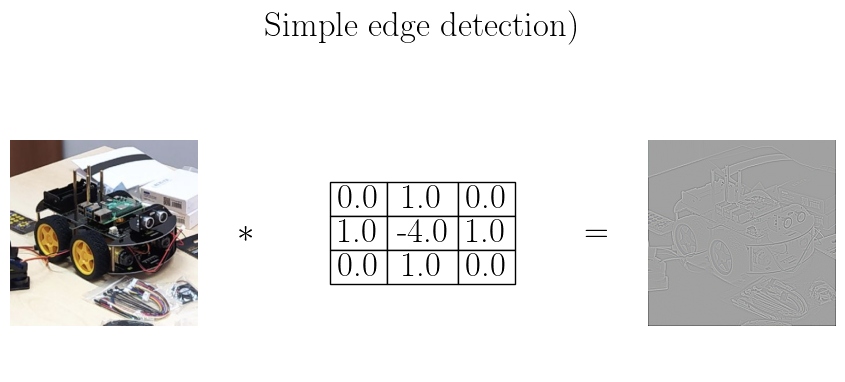

In [70]:
kernel = torch.tensor([
        [0, 1, 0],
        [1,-4, 1],
        [0, 1, 0]
    ], dtype=torch.float32)
plot_convolution_diagram(input_path, kernel, "Simple edge detection)")

## How does it work?

### Images as Numbers

An image is just a matrix of numbers:

- Grayscale image → 2D matrix
- Color image → 3 matrices (R, G, B)

Example:

If the image (3x5×5), then the red channel can be:
```
[ 10  20  30  40  50
  10  20  30  40  50
  20  30  40  50  60
  25  35  45  55  65
  30  40  50  60  70 ]
```

## Kernel (the filter)

A kernel is a small matrix which defines the operation. It can be for example an edge detection kernel:
```
[ 0  1 0
  1 -4 1
  0  1 0 ]
```

## Convolution (weighted sum)

```
            Image                  *       Kernel      =       Result    
                                                                         
┌───────────────────────────────┐                                        
│  [10   20   30]   40   50     │     ┌─────────────┐     ┌─────────────┐
│  [10   20   30]   40   50     │     │  0   1   0  │     |  10   .   . |
│  [20   30   40]   50   60     │  *  │  1  -4   1  │  =  |   .   .   . |
│   25   35   45    55   65     │     │  0   1   0  │     |   .   .   . |
│   30   40   50    60   70     │     └─────────────┘     └─────────────┘
└───────────────────────────────┘                                        

```

$$(20\cdot0 + 20\cdot1 + 30\cdot0) + (10\cdot1 - 20\cdot4 + 30\cdot1) + (20\cdot0 + 30\cdot1 + 40\cdot0) = $$
$$20 - 40 + 30 = $$
$$10.$$

## Convolution (weighted sum)

```
            Image                  *       Kernel      =       Result    
                                                                         
┌───────────────────────────────┐                                        
│   10  [20   30    40]  50     │     ┌─────────────┐     ┌─────────────┐
│   10  [20   30    40]  50     │     │  0   1   0  │     |  10  10   . |
│   20  [30   40    50]  60     │  *  │  1  -4   1  │  =  |   .   .   . |
│   25   35   45    55   65     │     │  0   1   0  │     |   .   .   . |
│   30   40   50    60   70     │     └─────────────┘     └─────────────┘
└───────────────────────────────┘                                        

```

$$(20\cdot0 + 30\cdot1 + 40\cdot0) + (20\cdot1 - 30\cdot4 + 40\cdot1) + (30\cdot0 + 40\cdot1 + 50\cdot0) = $$
$$30 - 60 + 40 = $$
$$10.$$

## Convolution (weighted sum)

```
            Image                  *       Kernel      =       Result    
                                                                         
┌───────────────────────────────┐                                        
│  [10   20   30]   40   50     │     ┌─────────────┐     ┌─────────────┐
│  [10   20   30]   40   50     │     │  0   1   0  │     |  10  10  10 |
│  [20   30   40]   50   60     │  *  │  1  -4   1  │  =  |  15  15  15 |
│   25   35   45    55   65     │     │  0   1   0  │     |   0   0   0 |
│   30   40   50    60   70     │     └─────────────┘     └─────────────┘
└───────────────────────────────┘                                        
```

In [66]:
import numpy as np

def convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    Perform a simple 2D convolution (no padding, stride=1).

    Parameters
    ----------
    image : np.ndarray
        Input 2D image array.
    kernel : np.ndarray
        Convolution kernel (smaller 2D array).

    Returns
    -------
    np.ndarray
        Convolved output.
    """
    h, w = image.shape
    kh, kw = kernel.shape

    output = np.zeros((h - kh + 1, w - kw + 1))

    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            region = image[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output


# Example
image = np.array([
    [10, 20, 30, 40, 50],
    [10, 20, 30, 40, 50],
    [20, 30, 40, 50, 60],
    [25, 35, 45, 55, 65],
    [30, 40, 50, 60, 70]
])

kernel = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])

output = convolve2d(image, kernel)
print(output)

[[10. 10. 10.]
 [-5. -5. -5.]
 [ 0.  0.  0.]]


## Other examples

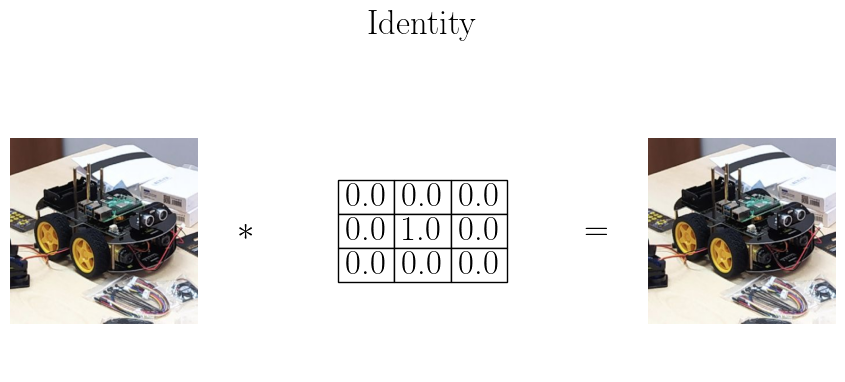

In [67]:
kernel = torch.tensor([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]
    ], dtype=torch.float32)
plot_convolution_diagram(input_path, kernel, "Identity")

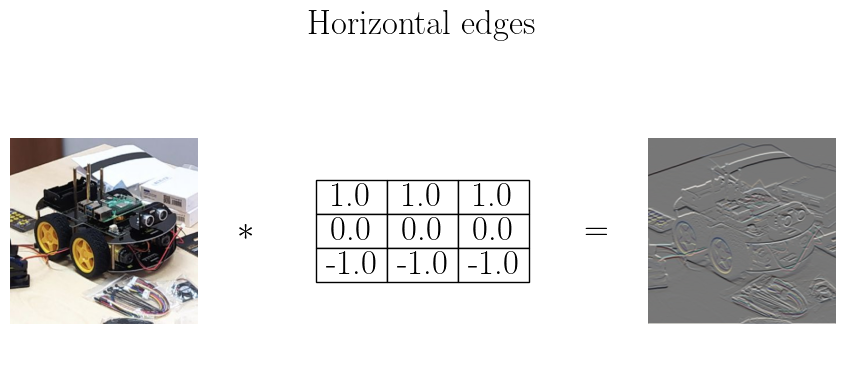

In [68]:
kernel = torch.tensor([
        [1, 1, 1],
        [0, 0, 0],
        [-1, -1, -1]
    ], dtype=torch.float32)
plot_convolution_diagram(input_path, kernel, "Horizontal edges")

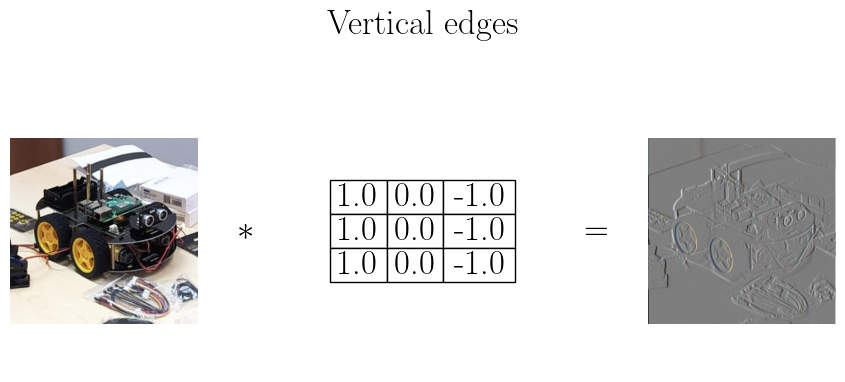

In [69]:
kernel = torch.tensor([
        [1, 0, -1],
        [1, 0, -1],
        [1, 0, -1]
    ], dtype=torch.float32)
plot_convolution_diagram(input_path, kernel, "Vertical edges")